<a href="https://colab.research.google.com/github/Kazureee/Machine-Learning-Lesson/blob/main/3_CLUSTERING_FINALS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from matplotlib import pyplot as plt

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/Health_Sleep_Statistics.csv')
df


,User ID,Age,Gender,Sleep Quality,Bedtime,Wake-up Time,Daily Steps,Calories Burned,Physical Activity Level,Dietary Habits,Sleep Disorders,Medication Usage
0,1,25,f,8,23:00,06:30,8000,2500,medium,healthy,no,no
1,2,34,m,7,00:30,07:00,5000,2200,low,unhealthy,yes,yes
2,3,29,f,9,22:45,06:45,9000,2700,high,healthy,no,no
3,4,41,m,5,01:00,06:30,4000,2100,low,unhealthy,yes,no
4,5,22,f,8,23:30,07:00,10000,2800,high,medium,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,43,m,7,00:45,07:15,6500,2400,medium,medium,no,no
96,97,33,f,8,23:15,06:15,8500,2600,high,medium,no,no
97,98,46,m,4,01:30,07:00,3000,2000,low,unhealthy,yes,yes
98,99,25,f,9,22:15,06:45,9500,2700,high,healthy,no,no


In [5]:
#convert Sleep Disorders into numeric
df['SleepDisordersNum'] = df['Sleep Disorders'].map({'yes': 1, 'no': 0})
df = df.rename(columns={'Daily Steps': 'Daily_steps'})
df = df.rename(columns={'Calories Burned': 'Calories_Burned'})
df = df.rename(columns={'Sleep Quality': 'Sleep_Quality'})

df

,User ID,Age,Gender,Sleep_Quality,Bedtime,Wake-up Time,Daily_steps,Calories_Burned,Physical Activity Level,Dietary Habits,Sleep Disorders,Medication Usage,SleepDisordersNum
0,1,25,f,8,23:00,06:30,8000,2500,medium,healthy,no,no,0
1,2,34,m,7,00:30,07:00,5000,2200,low,unhealthy,yes,yes,1
2,3,29,f,9,22:45,06:45,9000,2700,high,healthy,no,no,0
3,4,41,m,5,01:00,06:30,4000,2100,low,unhealthy,yes,no,1
4,5,22,f,8,23:30,07:00,10000,2800,high,medium,no,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,43,m,7,00:45,07:15,6500,2400,medium,medium,no,no,0
96,97,33,f,8,23:15,06:15,8500,2600,high,medium,no,no,0
97,98,46,m,4,01:30,07:00,3000,2000,low,unhealthy,yes,yes,1
98,99,25,f,9,22:15,06:45,9500,2700,high,healthy,no,no,0


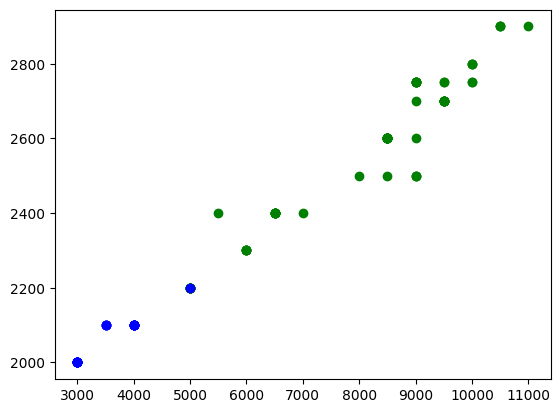

In [6]:

df1 = df[df.SleepDisordersNum == 0]
df2 = df[df.SleepDisordersNum == 1]

# Create the scatterplot with different colors for each group
plt.scatter(df1.Daily_steps, df1.Calories_Burned, color='green', label='Numeric Class 0')
plt.scatter(df2.Daily_steps, df2.Calories_Burned, color='blue', label='Numeric Class 1')

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
y = df.SleepDisordersNum
x = df[['Daily_steps', 'Calories_Burned', 'Sleep_Quality']]

#partition data(Training dataset (80), testing dataset (20))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

x_test

,Daily_steps,Calories_Burned,Sleep_Quality
5,6000,2300,6
83,5000,2200,6
84,8500,2600,8
6,8500,2600,8
22,9500,2750,9
85,4000,2100,5
62,9000,2750,9
21,4000,2100,5
1,5000,2200,7
20,9000,2600,8


In [8]:
#K Means Clustering (Training)
from sklearn.cluster import KMeans
km = KMeans(n_clusters=2)
km.fit_predict(x_train, y_train)

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0], dtype=int32)

In [9]:
#K Means prediction (Testing)
y_km_predicted = km.fit_predict(x_test)
y_km_predicted

array([1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0],
      dtype=int32)

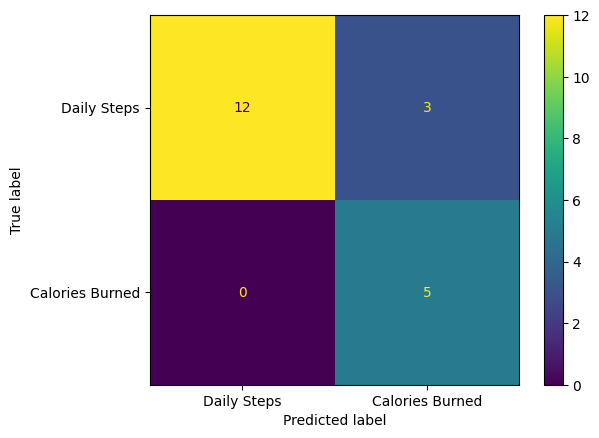

In [25]:
#Confusion Matrix (K Means) (Evalution)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_km_predicted)
cm

cm_display = ConfusionMatrixDisplay(cm, display_labels=['Daily Steps', 'Calories Burned'])
cm_display.plot()
plt.show()

In [11]:
#DBSCAN (Training)
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=12)
dbscan.fit_predict(x_train, y_train)

array([-1, -1, -1, -1, -1,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1,
        0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1,  0, -1, -1,
       -1, -1,  0, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1,  0, -1, -1,
       -1, -1, -1, -1,  0, -1,  0, -1, -1, -1, -1,  0])

In [12]:
#DBSCAN prediction (Testing)
y_dbscan_predicted = dbscan.fit_predict(x_test)
y_dbscan_predicted

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1])

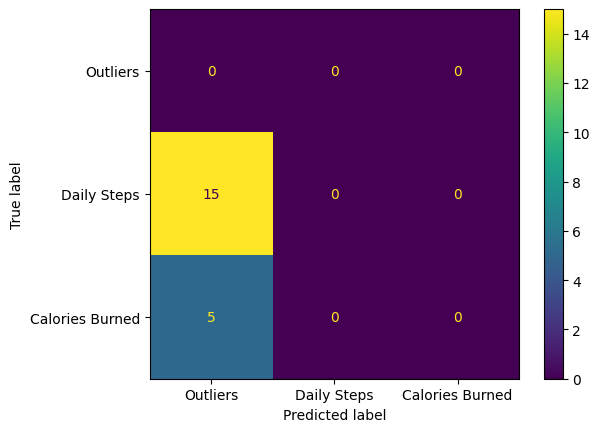

In [26]:
#Confusion Matrix (DBSCAN) (Evalution)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_dbscan_predicted)
cm

cm_display = ConfusionMatrixDisplay(cm, display_labels=['Outliers', 'Daily Steps', 'Calories Burned',])
cm_display.plot()
plt.show()

The dataset is not suitable for DBSCAN due to a lack of well-defined dense regions, excessive noise, or uniform point distribution, making clustering ineffective

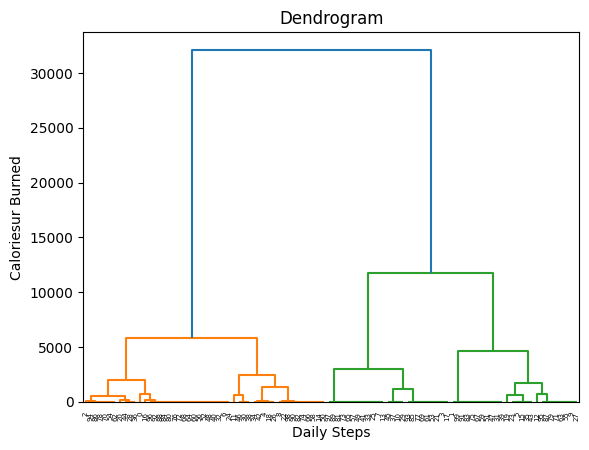

In [14]:
#Hierarchical Cluster
#Visualization
import scipy.cluster.hierarchy as sch
dendrogam = sch.dendrogram(sch.linkage(x, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Daily Steps')
plt.ylabel('Caloriesur Burned')
plt.show()

In [15]:
#training
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
hc.fit_predict(x_train, y_train)

array([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1])

In [22]:
#Testing
import numpy as np
y_hc_predicted = hc.fit_predict(x_test)

label_mapping = {0: 1, 1: 0}
y_hc_predicted_flipped = np.vectorize(label_mapping.get)(y_hc_predicted)
y_hc_predicted_flipped

array([1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0])

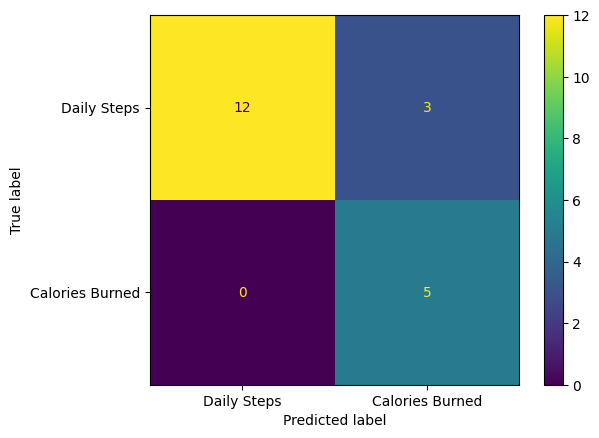

In [27]:
#Confusion Matrix (DBSCAN) (Evalution)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_hc_predicted_flipped)
cm

cm_display = ConfusionMatrixDisplay(cm, display_labels=['Daily Steps', 'Calories Burned'])
cm_display.plot()
plt.show()